## Oppgave 3 a)

In [ ]:
import numpy as np
from numba import njit
import math as math
import matplotlib.pyplot as plt

kb = 1.38 * 10**-23
T = 298
beta = 1/(kb*T)


@njit
def walk_dir(p_minus: float, p_plus: float) -> int:
    """Choose a random walk direction based on left/right move probabilities

    Args:
        p_minus: Probability of a move to the left (minus)
        p_plus: Probability of a move to the right (plus)

    Returns:
        step: Integer step value (-1, 0, or 1)
    """
    rand_val = np.random.ranf()
    if rand_val <= p_minus:
        return -1
    elif rand_val >= (1 - p_plus):
        return 1
    else:
        return 0


@njit
def v31(x: int, n_x: int, alpha: float, k: float) -> float:
    """Calculate the periodic potential V31 at position x

    Args:
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength

    Returns:
        v: Potential value at position x for V31
    """
    x_per = x % n_x
    if x_per < alpha * n_x:
        return k * x_per / (alpha * n_x * beta)
    else:
        x_per = x_per - n_x
        return -k * x_per / ((1 - alpha) * n_x * beta)


@njit
def v32(x: int, n_x: int, alpha: float, k: float) -> float:
    """Calculate the periodic potential V32 at position x

    Args:
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength

    Returns:
        v: Potential value at position x for V32
    """
    return 1 / beta


@njit
def probs_3(beta: float, x: int, n_x: int, alpha: float, k: float, t: int, t_p: int):
    """Calculate the probabilities of all possible moves with the partition function

    Args:
        beta: Constant equal to 1/Kb*T
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32

    Returns:
        p_minus, p_plus: Probabilites for a move to the left (minus) and right (plus)
    """
    # Checking for edge cases mentioned in 1c, this prevents unecessary calculations and underflow/overflow
    if -0.01/beta<(periodic_pot(t, t_p, x+1 , n_x, alpha, k) - periodic_pot(t, t_p, x, n_x, alpha, k))<0.01/beta:
        return 1/3,1/3
    elif 100<(periodic_pot(t, t_p, x+1, n_x, alpha, k) - periodic_pot(t, t_p, x, n_x, alpha, k)):
        return 1,0
    elif -100>(periodic_pot(t, t_p, x+1, n_x, alpha, k) - periodic_pot(t, t_p, x, n_x, alpha, k)):
        return 0,1
    
    # Calculating exponents
    b = -beta * (periodic_pot(t, t_p, x,     n_x, alpha, k) - periodic_pot(t, t_p, x + 1, n_x, alpha, k))
    a = -beta * (periodic_pot(t, t_p, x - 1, n_x, alpha, k) - periodic_pot(t, t_p, x + 1, n_x, alpha, k))
    c = -beta * (periodic_pot(t, t_p, x + 1, n_x, alpha, k) - periodic_pot(t, t_p, x - 1, n_x, alpha, k))
    d = -beta * (periodic_pot(t, t_p, x,     n_x, alpha, k) - periodic_pot(t, t_p, x - 1, n_x, alpha, k))

    p_plus = 1.0 / (1.0 + np.exp(a) + np.exp(b))
    p_minus = 1.0 / (1.0 + np.exp(c) + np.exp(d))

    return p_minus, p_plus


@njit
def periodic_pot(t: int, t_p: int, x: int, n_x: int, alpha: float, k: float) -> float:
    """Select the periodic potential based on the current time step

    Args:
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength

    Returns:
        v: Potential value at position x for the active potential (V31 or V32)
    """
    if t % (2 * t_p) < t_p:
        return v32(x, n_x, alpha, k)
    else:
        return v31(x, n_x, alpha, k)


@njit
def walk_step(n_x: int, alpha: float, k: float, n_p: int, t: int, t_p: int, x: np.ndarray, interval: int):
    """Perform one timestep of the random walk for all particles

    Args:
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        n_p: Number of particles
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32
        x: Array of particle positions
        interval: Maximum position value (wrap-around boundary)

    Returns:
        x: Updated array of particle positions after one timestep
        flow: Normalized net flow (n_plus - n_minus) / n_p for this timestep
    """

    n_plus = 0
    n_minus = 0
    # Finding and performing steps for all the particles
    for j in range(len(x)):
        p_minus, p_plus = probs_3(beta, x[j], n_x, alpha, k, t, t_p)
        step = walk_dir(p_minus, p_plus)

        if step == 1:
            n_plus += 1
            if x[j] == (interval-1):
                x[j] = 0
            else:
                x[j] += step
        elif step == -1:
            n_minus += 1
            if x[j] == 0:
                x[j] = interval-1
            else:
                x[j] += step
    flow = (n_plus - n_minus) / n_p
    return x, flow


def sim_3(t_p: int, n_x: int, alpha: float, k: float, n_p: int, cycles: int, interval: int):
    """Simulate the random walk with a switching periodic potential over multiple cycles

    Args:
        t_p: Time period between potential switches V31/V32
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        n_p: Number of particles
        cycles: Number of full cycles to simulate
        interval: length of position interval (wrap-around boundary)

    Returns:
        x: Final array of particle positions after all cycles
        avg_flow: Array of average flow per cycle
    """
    # Creating array with n_p elements (positions) in range [0,interval),
    # where there are n_p//interval repetitions of each position
    x = np.array([[i for _ in range((n_p // interval))] for i in range(interval)]).flatten()
    avg_flow = np.zeros(cycles)

    # Going through all periods t_p for all cycles and adding their J_avg to the avg_flow array
    for cycle in range(cycles):
        flow_t = np.zeros(2 * t_p)
        for t in range(2 * t_p):
            x, flow = walk_step(n_x, alpha, k, n_p, t, t_p, x, interval)
            flow_t[t] = flow
        avg_flow[cycle] = flow_t.sum() / (2 * t_p)

    return x, avg_flow


x_10, avg_flow_08 = sim_3(500, 100, 0.8, 1000, 1200, 10, 200)
x_10, avg_flow_01 = sim_3(500, 100, 0.1, 1000, 1200, 10, 200)

In [120]:
print(avg_flow_08)
print(avg_flow_01)


[-0.03116667 -0.01258333 -0.01325    -0.01283333 -0.01108333 -0.01291667
 -0.01466667 -0.01325    -0.01283333 -0.01341667]
[0.04041667 0.02925    0.028      0.02641667 0.02983333 0.02766667
 0.02775    0.0275     0.02816667 0.02733333]


### i)
Vi får ikke-null partikkelstrømmer fordi potensial 1 har en positiv derivert for 80% av tall linjen, mot de 20%ene som er dekt av den negative deriverte. Selvom vi gjennom en hel syklus i posisjoner for potensial 1 går fra minimum til maksimum tilbake til minimum, vil vi fortsatt ha flere partikler som beveger seg til venstre for hver iterasjon da sum av skritt ikke er direkte proposjonal med magnitude av gradienten til potensialet ganget med område den dekker.

Fysiskt kan dette forklares med at vi har et område delt inn i mange seksjoner på en meter, der vi kan forskyve inndelingene litt for å få en potensialfunskjon med en dal i hver inndeling der vi starter på -0.2 meter og går til 0.8 osv gjennom område. Her vil potensialet være like maksimalt for -0.2 og 0.8 meter, og gå lineært ned mot minmium ved 0 meter. For å oppnå lavest potensiell energi vil alle partiklene bevege seg til posisjonen ved 0 meter, her kan vi se at hvis partiklene orginalt er jevnt fordelt vil flere partikler gå mot venstre enn høyre, som resulterer i en negativ gjennomsnittlig partikkelflyt ($J_{avg}$).


### ii)
Vi ser at den første målingen av $J_{avg}$ er betydelig større enn alle de andre målingene som er relatvit like. Dette an forklares ved at partiklene orginalt er jevt fordelt for å så bevege seg slik at de i praksis alle er ved minimalt potensial under potensial 1, deretter byttes potensialet til potensial 2 som er konstant, og fører til tilfeldig bevegelse, på grunn av at denne tilfeldige bevegelsen skjer i en veldig begrenset tidsperiode, og at partiklene i utgangspunktet alle er veldig nær posisjon 0, forventer vi at de er betydelig nærmere posisjon 0 enn når de var jevnt fordelte ved tidspunktet der vi bytter tilbake til potensial 1. Dette gjør at vi får mindre bevegelse og derfor en lavere $J_{avg}$.


### iii)
Her ser vi at $J_{avg}$ er mot høyre isteden for venstre (positiv isteden for negativ) som vi forventer da potensial 1 nå har mye større del med negativ derivert enn positiv derivert. 



Oppgave 3 b)

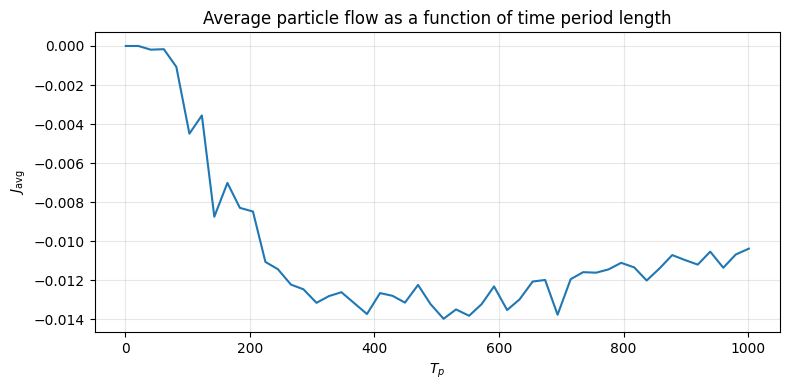

In [121]:
@njit
def sim_3b(t_p: int, n_x: int, alpha: float, k: float,
           n_p: int, pos1: int, pos2: int, interval: int):
    """Simulate the random walk with a switching periodic potential for two particle groups

    Args:
        t_p: Time period between potential switches V31/V32
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        n_p: Number of particles
        pos1: Initial position of the first group of particles
        pos2: Initial position of the second group of particles
        interval: Length of position interval (wrap-around boundary)

    Returns:
        x: Final array of particle positions after one cycle
        avg_flow: Average flow over one full cycle
    """
    # Making an array of particles equally divided between position 1 and 2
    x = np.array([[pos1 for _ in range(n_p // 2)],
                  [pos2 for _ in range(n_p // 2)]]).flatten()

    flow_t = np.zeros(2 * t_p)

    for t in range(2 * t_p):
        x, flow = walk_step(n_x, alpha, k, n_p, t, t_p, x, interval)
        flow_t[t] = flow
    avg_flow = np.mean(flow_t)

    return x, avg_flow


def plotter(titles: np.ndarray, x_labels: np.ndarray, y_labels: np.ndarray, x_arrays: np.ndarray, y_arrays: np.ndarray, rows: int, cols: int, size = (8,4), collective_title = ""):
    """Plot multiple x/y datasets across one or more subplots

    Args:
        titles: Array of titles, one per subplot
        x_labels: Array of x axis labels, one per subplot
        y_labels: Array of y axis labels, one per subplot
        x_arrays: Array of x axis value arrays, one per graph
        y_arrays: Array of y axis value arrays, one per graph
        rows: Number of subplot rows
        cols: Number of subplot columns

    Returns:
        None
    """
    fig, ax = plt.subplots(rows, cols, figsize=size)
    axes_flattened = ax.flatten() if rows*cols > 1 else [ax]
    # Making repeating axes array for plotting multiple graphs in one plot
    # For example if we want 2 graphs per plot: [ax_0, ax_1] --> [ax_0, ax_0, ax_1, ax_1]
    if len(axes_flattened) < len(x_arrays):
        graphs_per_plot = len(x_arrays) // len(axes_flattened)
        new_axes_list = []
        for ax in axes_flattened:
            for _ in range(graphs_per_plot):
                new_axes_list.append(ax)
        axes_flattened = np.array(new_axes_list)
    else:
        graphs_per_plot = 1
    # Simple plotting for every x_arrays[i] and y_arrays[i] pair.
    for i, ax in enumerate(axes_flattened):
        ax.plot(x_arrays[i], y_arrays[i])
        if i % graphs_per_plot == 0:
            ax.set_xlabel(x_labels[i//graphs_per_plot])
            ax.set_ylabel(y_labels[i//graphs_per_plot])
            ax.set_title(titles[i//graphs_per_plot])
            ax.grid(True, alpha=0.3)
    if collective_title:
        fig.suptitle(collective_title)
    fig.tight_layout()

# Initializing t_p array with 50 evenly spaced t_p values and empty flow array with same length of type np.float64
t_p_array = np.int64(np.linspace(1, 1001, 50))
flow_array_3b = np.zeros(len(t_p_array), dtype=np.float64)

# Simulating the J_avg for all values of t_p and adding them to flow array for plotting
for i in range(len(t_p_array)):
    x, avg_flow_3b = sim_3b(t_p_array[i], 100, 0.8, 1000, 40 * 100, 100, 200, 200)
    flow_array_3b[i] = avg_flow_3b

plotter(np.array(["Average particle flow as a function of time period length"]), np.array([r"$T_p$"]), np.array([r"$J_{\mathrm{avg}}$"]), np.array([t_p_array]), np.array([flow_array_3b]), 1, 1)
plt.show()

### i)
Vi observer at magnituden $J_{avg}$ starter rundt null, for å så gå opp til et maksimum ved $T_p \in [350, 550]$, magnituden av flyten minker etter dette. En tolkning av den initielle økningen i magnitude er at partiklene trenger noe tid for å spre seg utover mens potensial 2 er aktivt for at vi skal se noe utslag i $J_{avg}$. Dette kan forklares ved at partiklene vil gå veldig lite vekk fra minimum i potensial 1 ved et lavt antall tidssteg som fører til at veien tilbake til minimum er like lang uavhengig av hvilken ve de gikk da asymmetrien i potensialet i prakisis "ikke oppdages" av partiklene, dette gjør da at $J_{avg}$ blir null.

For å forklare hvorfor magnituden igjen går ned ved en tilstrekkelig høy verdi for $T_p$, kan vi se på formelen for å regne ut $J_{avg}$. Vi har tenkt oss at denne er i noen grad porposjonal med hvor langt partiklene er unna minimumet i potensial 1, dette vil i vårt tilfelle makismeres når partiklene er uniformt fordelt, når vi ser bort fra ekstremt usannsynlige tilfeller. videre vet vi at $J_{avg}$ er lineært omvendtproposjonalt med T_p, mens den gjennomsnittlige avstanden fra en partikkel til minimum i potensial 1 er avvtakende proposjonal $T_p$. Dette gjør at vi vil får en kamp mellom det positive bidraget til magnitudena v flyten fra $T_p$ som har en negativ derivert, og det negative bidraget fra $T_p$ som har en konstant derivert, gitt at det positive bidraget starter større enn det negative må vi da finne et eller annet punkt $T_{p_{maks}} > T_{p_0}$ der magnituden av $J_{avg}$ maksimeres.

## Oppgave 3 c)

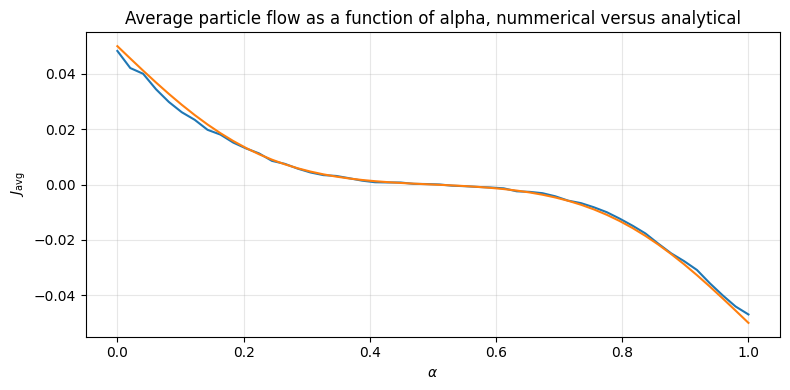

In [122]:
import math as math

def analytic_flow(n_x: int, t_p: int, alpha: float):
    """Calculate the analytical average particle flow as a function of alpha

    Args:
        n_x: Length of intervall for periodic potential V31
        t_p: Time period between potential switches V31/V32
        alpha: Position of potential switch within n_x, pos = n_x*alpha

    Returns:
        flow: Analytical average particle flow for the given parameters
    """
    return n_x/(4*t_p) * (
        math.erfc(alpha*n_x/2*np.sqrt(3/t_p))
        - math.erfc((1-alpha)*n_x/2*np.sqrt(3/t_p))
    )




# Initializing alpha array with 50 evenly spaced t_p values and empty flow arrays with same length of type np.float64
alpha_array = np.linspace(0, 1, 50)
flow_array_3c = np.zeros(len(alpha_array), dtype=np.float64)
analytic_flow_array_3c = np.zeros(len(alpha_array), dtype=np.float64)

# Simulating the J_avg for all values of alpha and adding them to flow arrays for plotting
for i in range(len(alpha_array)):
    x, avg_flow = sim_3b(500, 100, alpha_array[i], 1000, 40*100, 0, 100, 200)
    flow_array_3c[i] = avg_flow
    analytic_flow_array_3c[i] = analytic_flow(100, 500, alpha_array[i])

plotter(np.array(["Average particle flow as a function of alpha, nummerical versus analytical"]),
         np.array([r"$\alpha$"]), np.array([r"$J_{\mathrm{avg}}$"]),
         np.array([alpha_array for _ in range(2)]), np.array([flow_array_3c,analytic_flow_array_3c]), 1, 1)





Den nummeriske løsningen vår er veldig lik den analytiske løsningen som tyder på at oppgaven er løst rett. Vi ser en korrelasjon mellom $|\alpha-0.5|$ og magnituden av $J_{avg}$, vi kan se at magnituden av den andre deriverte av funksjonen når maks rundt $\alpha = 0.75$ og $\alpha = 0.25$.

## Oppgave 3 d)

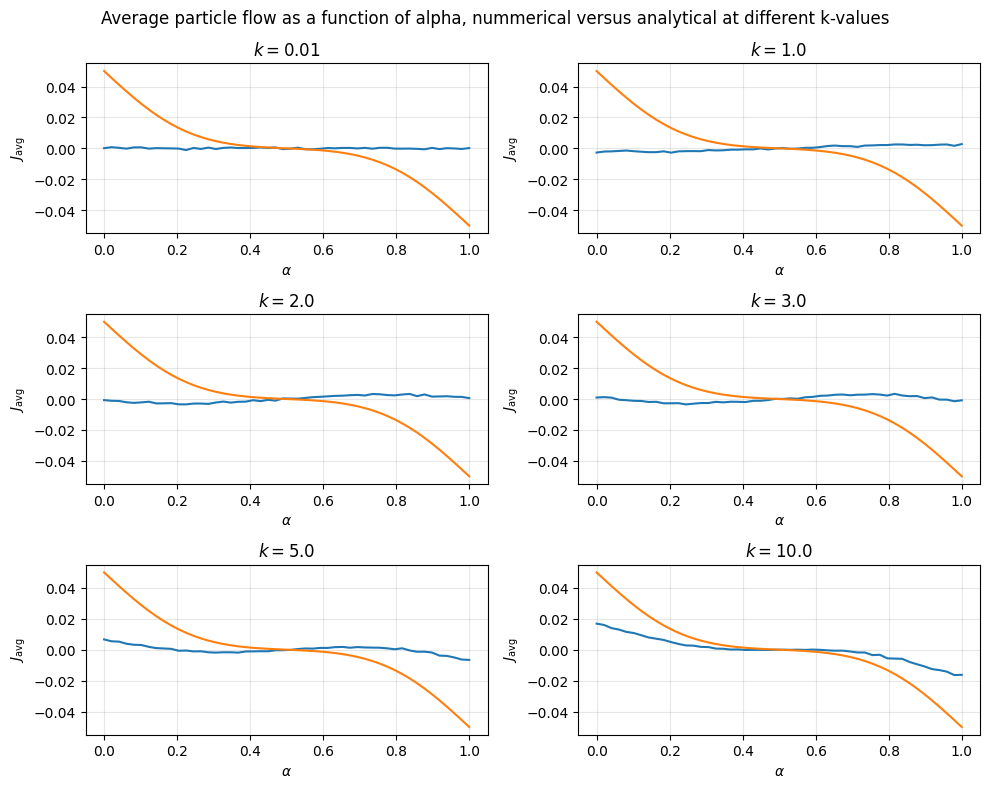

In [123]:
k_array = np.array([0.01, 1, 2, 3, 5, 10])
flow_array_list = []
for k in k_array:
    # Initializing alpha array with 50 evenly spaced t_p values and empty flow arrays with same length of type np.float64
    alpha_array = np.linspace(0, 1, 50)
    flow_array_3d = np.zeros(len(alpha_array), dtype=np.float64)
    analytic_flow_array_3d = np.zeros(len(alpha_array), dtype=np.float64)

    # Simulating the J_avg for all values of alpha and adding them to a list of flow arrays for plotting
    for i in range(len(alpha_array)):
        x, avg_flow = sim_3b(500, 100, alpha_array[i], k, 40*100, 100, 200, 300)
        flow_array_3d[i] = avg_flow
        analytic_flow_array_3d[i] = analytic_flow(100, 500, alpha_array[i])
    flow_array_list.append(flow_array_3d)
    flow_array_list.append(analytic_flow_array_3d)
flow_arrays = np.array(flow_array_list)

title_array = np.array([rf"$k = {k}$" for k in k_array])

plotter(title_array, np.array([r"$\alpha$" for _ in range(len(k_array))]),
         np.array([r"$J_{\mathrm{avg}}$" for _ in range(len(k_array))]),
         np.array([alpha_array for _ in range(len(k_array)*2)]), flow_arrays, 3, 2,(10,8),
         "Average particle flow as a function of alpha, nummerical versus analytical at different k-values")


## Oppgave 3 e)

In [124]:
# Initializing t_p array with 50 evenly spaced t_p values and empty flow array with same length of type np.float64
t_p_array = np.int64(np.linspace(80, 1500, 50))
flow_array_3b = np.zeros(len(t_p_array), dtype=np.float64)

# Simulating the J_avg for all values of t_p and adding them to flow array for plotting
for i in range(len(t_p_array)):
    x, avg_flow_3b = sim_3b(t_p_array[i], 100, 0.8, 1000, 40 * 100, 0, 10, 20)
    flow_array_3b[i] = avg_flow_3b

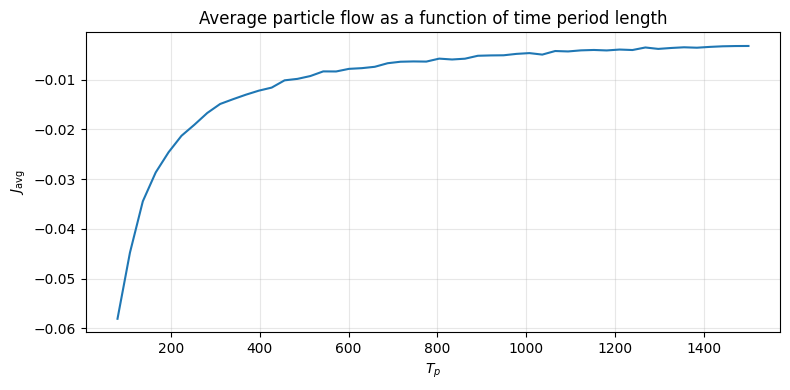

In [125]:
plotter(np.array(["Average particle flow as a function of time period length"]), np.array([r"$T_p$"]), np.array([r"$J_{\mathrm{avg}}$"]), np.array([t_p_array]), np.array([flow_array_3b]), 1, 1)
plt.show()


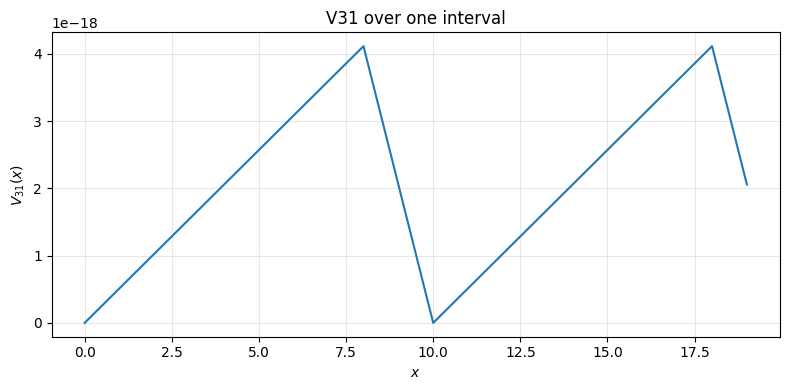

In [126]:
x_vals = np.arange(0, 20)
v_vals = np.array([v31(x, 10, 0.8, 1000) for x in x_vals])

plotter(
    np.array(["V31 over one interval"]),
    np.array([r"$x$"]),
    np.array([r"$V_{31}(x)$"]),
    np.array([x_vals]),
    np.array([v_vals]),
    1, 1
)
plt.show()